[TRAIN] Creato con 28743 campioni. (Norm: zscore)
[TRAIN] Creato con 28743 campioni. (Norm: None)
x_endo shape: torch.Size([8, 100]), x_exo shape: torch.Size([18, 100]), x_cond shape: torch.Size([9]), y_target shape: torch.Size([1, 25])


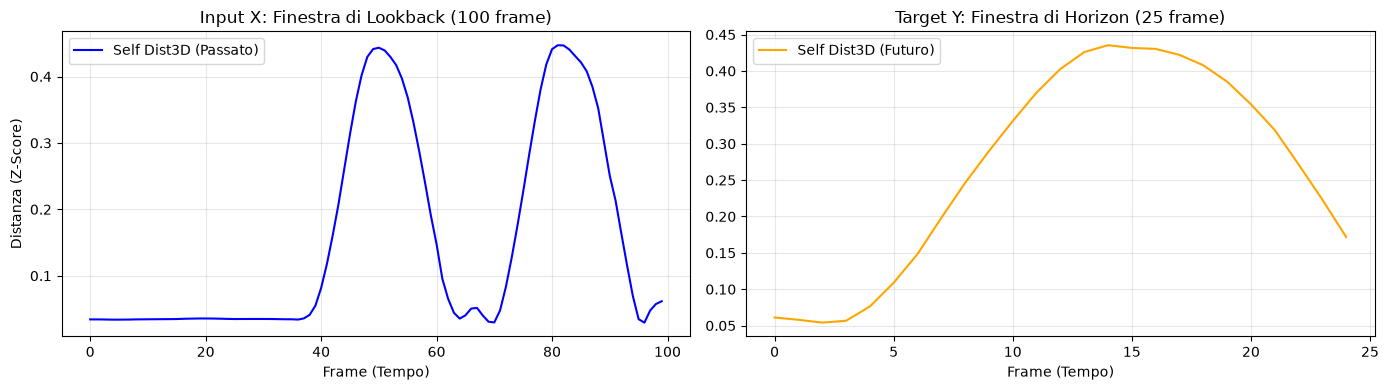

In [1]:
import sys

# Diamo a Python il percorso ASSOLUTO ed esatto del tuo progetto
sys.path.insert(0, '/home/jessica/TempSimul')

from lib.Dataloaders.VirtualAgentDataset import VirtualAgentDataset
import matplotlib.pyplot as plt

# 1. Carica il dataset
DATA_PATH = "/home/jessica/storage/VA_Dataset_Tensor.npz"
data = VirtualAgentDataset(DATA_PATH, split='train', norm='zscore')

from lib.Dataloaders.VirtualAgentDataset import VirtualAgentDataset
import matplotlib.pyplot as plt

# 1. Carica il dataset (usa il percorso assoluto per evitare problemi di path)
DATA_PATH = "/home/jessica/storage/VA_Dataset_Tensor.npz"
data = VirtualAgentDataset(DATA_PATH, split='train', norm=None)

# 2. Estrai il PRIMO campione tramite il metodo __getitem__
# x_endo avrà forma (8, 100) -> (Canali, Tempo)
# y_target avrà forma (1, 10) -> (Canale_Target, Tempo_Futuro)
x_endo, x_exo, x_cond, y_target = data[2000]  # Cambia l'indice per vedere campioni diversi
print(f"x_endo shape: {x_endo.shape}, x_exo shape: {x_exo.shape}, x_cond shape: {x_cond.shape}, y_target shape: {y_target.shape}")

# 3. Creiamo una figura con due grafici affiancati
plt.figure(figsize=(14, 4))

# --- PLOT 1: Il Passato (Lookback) ---
plt.subplot(1, 2, 1)
# Plottiamo il canale 0 (il 'Self') lungo tutto il lookback
plt.plot(x_endo[0, :].numpy(), color='blue', label='Self Dist3D (Passato)')
plt.title("Input X: Finestra di Lookback (100 frame)")
plt.xlabel("Frame (Tempo)")
plt.ylabel("Distanza (Z-Score)")
plt.legend()
plt.grid(True, alpha=0.3)

# --- PLOT 2: Il Futuro (Horizon) ---
plt.subplot(1, 2, 2)
# Plottiamo l'unico canale del target lungo tutto l'horizon
plt.plot(y_target[0, :].numpy(), color='orange', label='Self Dist3D (Futuro)')
plt.title("Target Y: Finestra di Horizon (25 frame)")
plt.xlabel("Frame (Tempo)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [2]:
import matplotlib.pyplot as plt

def debug_visivo_completo(dataset, idx=0, split_name="Dataset"):
    # Estraiamo i 4 tensori dal Dataloader
    x_endo, x_exo, x_cond, y_target = dataset[idx]
    
    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(f"Dashboard Debug - {split_name} | Indice Campione: {idx}", fontsize=16, fontweight='bold')

    # --- PLOT 1: X_endo (Il Passato: Distanze) ---
    ax1 = plt.subplot(2, 2, 1)
    ax1.plot(x_endo[0, :].numpy(), label='Self (Canale 0)', color='blue', linewidth=2)
    ax1.plot(x_endo[1, :].numpy(), label='Other 1 (Canale 1)', color='lightblue', alpha=0.8)
    ax1.set_title("X_endo: Distanze 3D Passate (Lookback)")
    ax1.set_xlabel("Frame")
    ax1.set_ylabel("Z-Score")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- PLOT 2: X_exo (Variabili Ambientali) ---
    # In Extract_VA.py i canali Exo sono: 0-1:Prua, 2:Angolo, 3:Metronomo, ecc...
    ax2 = plt.subplot(2, 2, 2)
    ax2.plot(x_exo[2, :].numpy(), label='Angolo Barca (Canale 2)', color='green', linewidth=1.5)
    ax2.plot(x_exo[3, :].numpy(), label='Metronomo (Canale 3)', color='red', linestyle='dashed')
    ax2.set_title("X_exo: Variabili Esogene")
    ax2.set_xlabel("Frame")
    ax2.set_ylabel("Z-Score")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # --- PLOT 3: Y_target (Il Futuro) ---
    ax3 = plt.subplot(2, 2, 3)
    ax3.plot(y_target[0, :].numpy(), label='Target Futuro', color='orange', linewidth=2)
    ax3.set_title("Y_target: Orizzonte Futuro (Horizon)")
    ax3.set_xlabel("Frame Futuri")
    ax3.set_ylabel("Z-Score")
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # --- PLOT 4: X_cond (Variabili Statiche Condizionali) ---
    ax4 = plt.subplot(2, 2, 4)
    cond_np = x_cond.numpy()
    # Usiamo un grafico a barre perché sono dati statici per tutta la finestra temporale
    ax4.bar(range(len(cond_np)), cond_np, color='purple', alpha=0.7)
    ax4.set_title("X_cond: Variabili Statiche (RowSide, TeamScore)")
    ax4.set_xlabel("Indice Feature (0: Self Lato, 1-7: Others Lato, 8: Score)")
    ax4.set_xticks(range(len(cond_np)))
    ax4.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    # plt.subplots_adjust(top=0.9) # Scommenta se il titolo si sovrappone
    plt.show()

[TRAIN] Creato con 28743 campioni. (Norm: zscore)
[VAL] Creato con 6159 campioni. (Norm: zscore)
[TEST] Creato con 6160 campioni. (Norm: zscore)


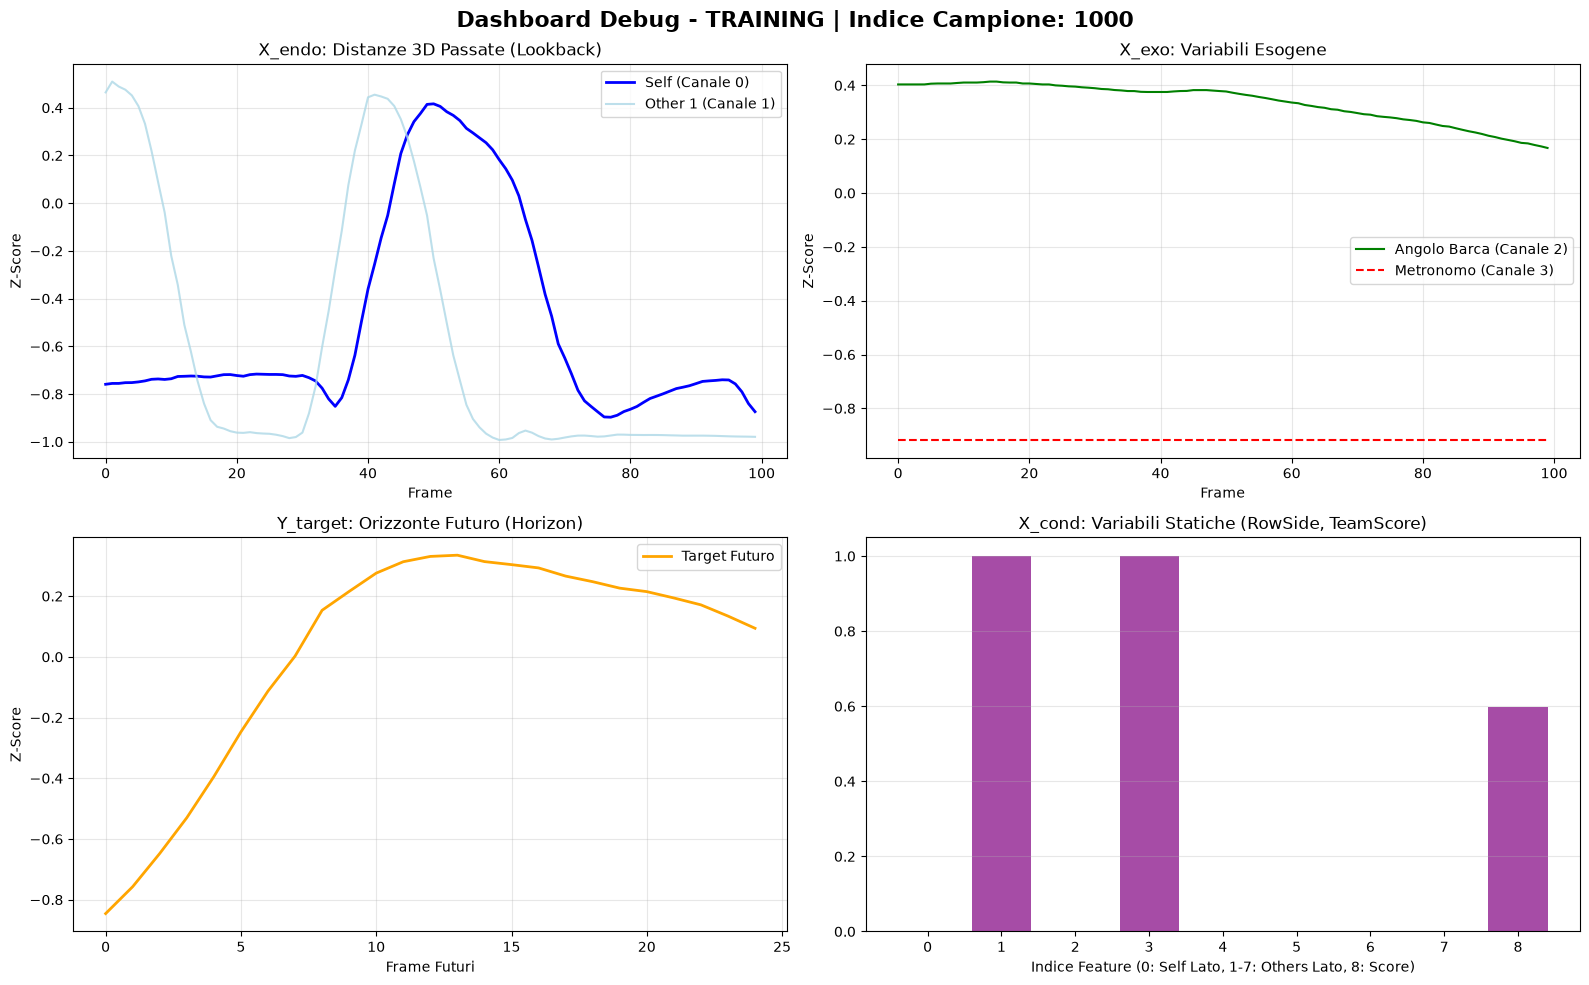

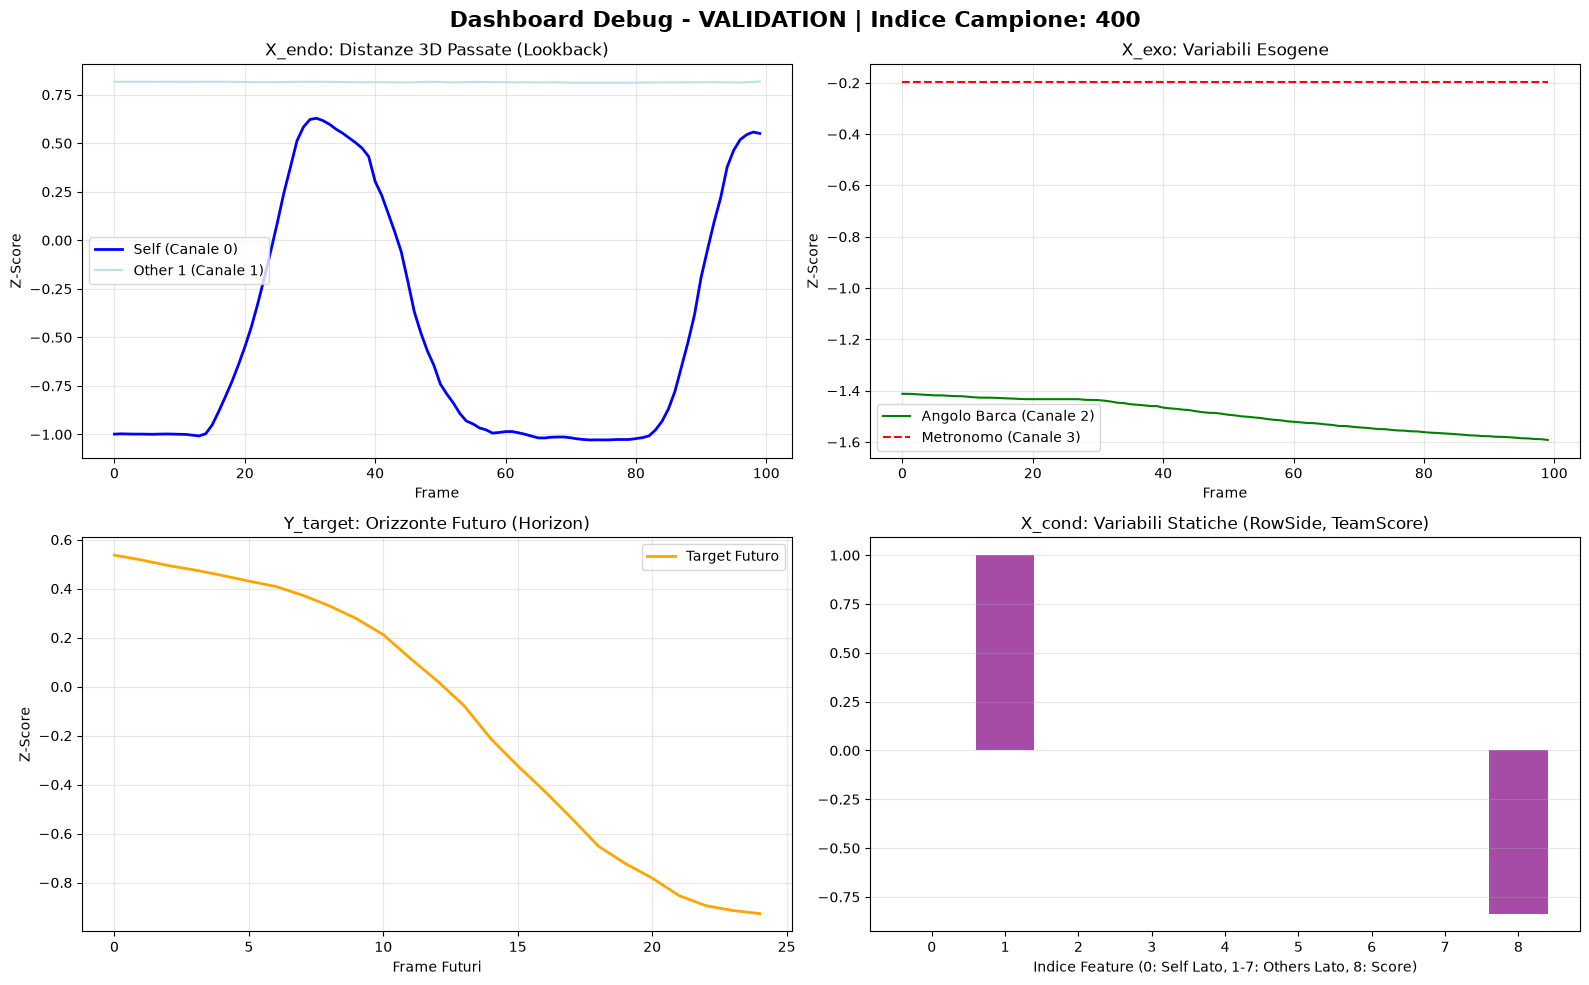

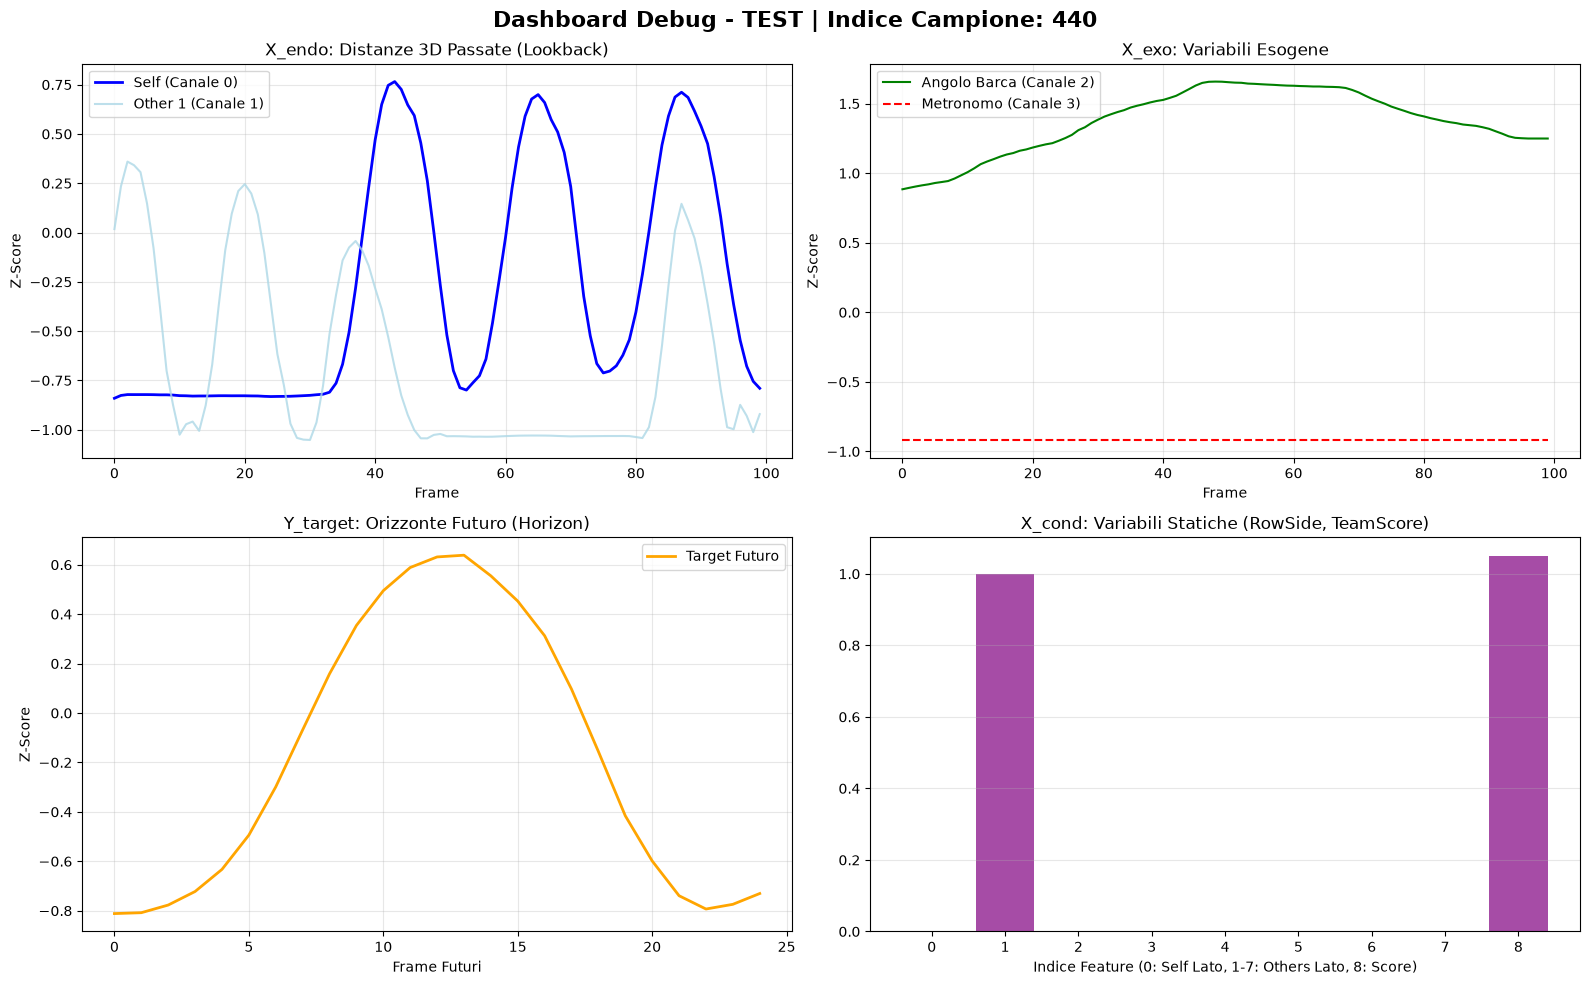

In [3]:
# Crea le istanze del dataloader con la normalizzazione attiva
DATA_PATH = "/home/jessica/storage/VA_Dataset_Tensor.npz"
train_dataset = VirtualAgentDataset(DATA_PATH, split='train', norm='zscore')
val_dataset = VirtualAgentDataset(DATA_PATH, split='val', norm='zscore')
test_dataset = VirtualAgentDataset(DATA_PATH, split='test', norm='zscore')

# 1. Guarda il campione 1500 del TRAINING
debug_visivo_completo(train_dataset, idx=1000, split_name="TRAINING")

# 2. Guarda il campione 400 della VALIDATION
debug_visivo_completo(val_dataset, idx=400, split_name="VALIDATION")

# 3. Guarda il primissimo campione del TEST
debug_visivo_completo(test_dataset, idx=440, split_name="TEST")